# A discrete bottleneck: VQ-VAE on the digits\nThe encoder returns one vector, the nearest of $K$ learned codes replaces it, and the decoder sees only that code. Labels are never used for training.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch import nn

torch.manual_seed(26520); np.random.seed(26520)
frame = pd.read_csv('SklearnDigits.csv')
pixels, labels = frame.drop(columns='target').to_numpy(float), frame['target'].to_numpy(int)

X = torch.tensor(pixels / 16.0, dtype=torch.float32)
n, d = X.shape
print(f'{n} images, {d} pixels each')

1797 images, 64 pixels each


## The model\nThree sets of parameters: encoder weights, the codebook, decoder weights. The straight-through trick sends $z_q$ forward and copies the gradient back to $z_e$.

In [2]:
class VQVAE(nn.Module):
    """Encoder -> nearest codebook entry -> decoder.

    Learnable parameters: encoder weights, the K code vectors, decoder weights.
    There is no sigma and no KL: the bottleneck is a lookup, not a sample.
    """
    def __init__(self, codes=16, width=4, hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, width))
        self.codebook = nn.Embedding(codes, width)
        self.codebook.weight.data.uniform_(-1 / codes, 1 / codes)
        self.decoder = nn.Sequential(nn.Linear(width, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, d))

    def quantize(self, z_e):
        distance = torch.cdist(z_e, self.codebook.weight)      # (batch, codes)
        index = distance.argmin(dim=1)
        return self.codebook(index), index

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, index = self.quantize(z_e)
        straight_through = z_e + (z_q - z_e).detach()          # forward z_q, backward identity
        return self.decoder(straight_through), z_e, z_q, index

## Training\nThe loss is reconstruction $+$ codebook $+$ commitment. The `.detach()` calls are the stop-gradients: each term moves exactly one end of the pair.

In [3]:
def train(codes=16, width=4, commitment=0.25, epochs=250, seed=26520, lr=2e-3, batch=128):
    torch.manual_seed(seed)
    model = VQVAE(codes=codes, width=width)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    generator = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        order = torch.randperm(n, generator=generator)
        for start in range(0, n, batch):
            xb = X[order[start:start + batch]]
            logits, z_e, z_q, _ = model(xb)
            reconstruction = nn.functional.binary_cross_entropy_with_logits(logits, xb, reduction='sum') / len(xb)
            codebook_loss = ((z_e.detach() - z_q) ** 2).sum(dim=1).mean()      # moves the code
            commitment_loss = ((z_e - z_q.detach()) ** 2).sum(dim=1).mean()    # moves the encoder
            optimizer.zero_grad()
            (reconstruction + codebook_loss + commitment * commitment_loss).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        logits, _, _, index = model(X)
        counts = torch.bincount(index, minlength=codes).float()
        share = counts / counts.sum()
        alive = share[share > 0]
        report = dict(
            reconstruction=nn.functional.binary_cross_entropy_with_logits(logits, X, reduction='sum').item() / n,
            counts=counts.numpy(), index=index.numpy(),
            active=int((counts > 0).sum()),
            perplexity=float(torch.exp(-(alive * alive.log()).sum())))
    return model, report


model, report = train(codes=16)
print(f'reconstruction {report["reconstruction"]:.1f} nats')
print(f'{report["active"]} of 16 codes ever used; perplexity {report["perplexity"]:.1f}')

reconstruction 21.2 nats
16 of 16 codes ever used; perplexity 14.4


## Reconstructions, and the code each image received

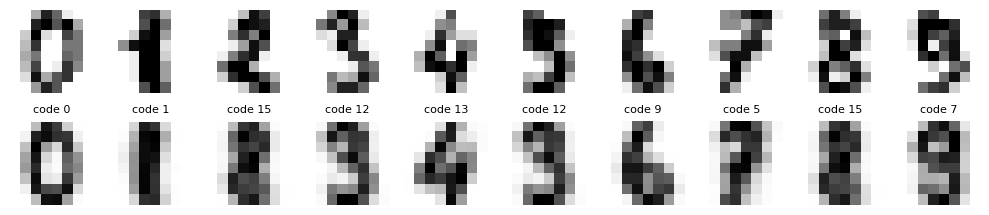

Two digits sharing a code must come back as the same image.


In [4]:
index = [int(np.where(labels == digit)[0][0]) for digit in range(10)]
with torch.no_grad():
    logits, _, _, chosen = model(X[index])
    rebuilt = torch.sigmoid(logits).numpy()

fig, axes = plt.subplots(2, 10, figsize=(10, 2.4))
for column, row in enumerate(index):
    axes[0, column].imshow(X[row].numpy().reshape(8, 8), cmap='gray_r'); axes[0, column].axis('off')
    axes[1, column].imshow(rebuilt[column].reshape(8, 8), cmap='gray_r'); axes[1, column].axis('off')
    axes[1, column].set_title(f'code {chosen[column].item()}', fontsize=8)
axes[0, 0].set_ylabel('data'); axes[1, 0].set_ylabel('decoded')
plt.tight_layout(); plt.show()

print('Two digits sharing a code must come back as the same image.')

## Which codes get used\nA code that is never nearest to anything receives no gradient from the codebook term, so it stays where it was initialized. **Perplexity** $\\exp(-\\sum_k p_k\\log p_k)$ reports the effective vocabulary size.

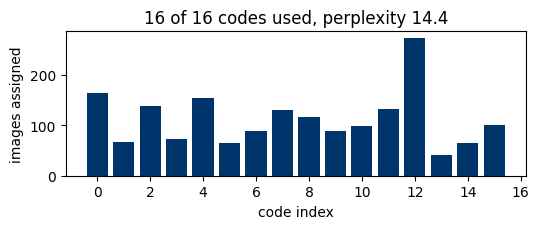

Grey bars are dead codes: never selected, so never updated by the codebook term.


In [5]:
fig, ax = plt.subplots(figsize=(5.5, 2.4))
ax.bar(np.arange(len(report['counts'])), report['counts'], color=['#00356B' if c else '#D8E0E8'
                                                                 for c in report['counts']])
ax.set(xlabel='code index', ylabel='images assigned',
       title=f'{report["active"]} of {len(report["counts"])} codes used, perplexity {report["perplexity"]:.1f}')
plt.tight_layout(); plt.show()

print('Grey bars are dead codes: never selected, so never updated by the codebook term.')

## The whole vocabulary\nWith one code per image, decoding every codebook entry shows everything this model can ever produce.

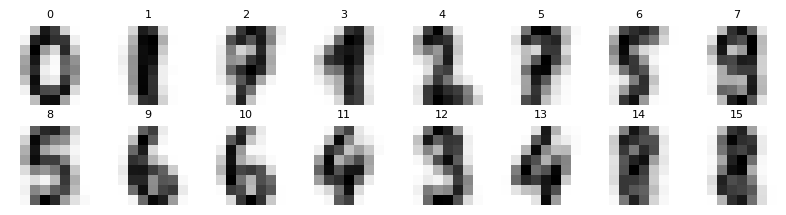

In [6]:
with torch.no_grad():
    vocabulary = torch.sigmoid(model.decoder(model.codebook.weight)).numpy()

fig, axes = plt.subplots(2, 8, figsize=(8, 2.2))
for code, (ax, image) in enumerate(zip(axes.ravel(), vocabulary)):
    ax.imshow(image.reshape(8, 8), cmap='gray_r'); ax.axis('off')
    ax.set_title(f'{code}' + ('' if report['counts'][code] else ' (dead)'), fontsize=8)
plt.tight_layout(); plt.show()

## Does a bigger codebook help?

In [7]:
rows = []
for codes in (4, 16, 64):
    _, summary = train(codes=codes, epochs=150)
    rows.append((codes, summary['reconstruction'], summary['active'], summary['perplexity']))
    print(f'K={codes:<3} reconstruction {summary["reconstruction"]:6.1f} nats   '
          f'active {summary["active"]:>2}/{codes}   perplexity {summary["perplexity"]:.1f}')

table = pd.DataFrame(rows, columns=['K', 'reconstruction (nats)', 'active codes', 'perplexity'])
table

K=4   reconstruction   24.8 nats   active  4/4   perplexity 2.6


K=16  reconstruction   21.5 nats   active 16/16   perplexity 14.6


K=64  reconstruction   20.4 nats   active 51/64   perplexity 32.1


,K,reconstruction (nats),active codes,perplexity
0,4,24.846772,4,2.645479
1,16,21.516881,16,14.585933
2,64,20.363459,51,32.050087


## Generation is a second stage

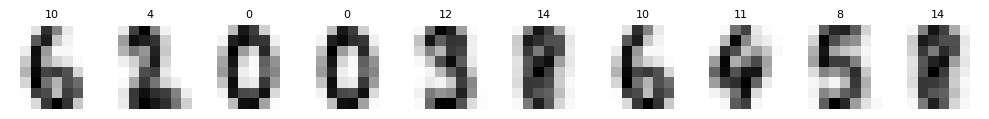

One integer per image means the model can produce at most K distinct pictures.
Real VQ-VAEs quantize a grid of positions, so an image becomes a grid of integers
and the stage-two model has a sequence to predict.


In [8]:
# Stage two: a model over code indices. With one code per image the "sequence
# model" is just a categorical distribution, which we can read off the data.
share = report['counts'] / report['counts'].sum()
draws = np.random.default_rng(0).choice(len(share), size=10, p=share)
with torch.no_grad():
    sampled = torch.sigmoid(model.decoder(model.codebook(torch.tensor(draws)))).numpy()

fig, axes = plt.subplots(1, 10, figsize=(10, 1.3))
for ax, image, index in zip(axes, sampled, draws):
    ax.imshow(image.reshape(8, 8), cmap='gray_r'); ax.axis('off'); ax.set_title(f'{index}', fontsize=8)
plt.tight_layout(); plt.show()

print('One integer per image means the model can produce at most K distinct pictures.')
print('Real VQ-VAEs quantize a grid of positions, so an image becomes a grid of integers')
print('and the stage-two model has a sequence to predict.')